# $\quad  \textit{Options on electricity futures pricing for the German Market}$

# Implementation of the 4-step protocol from the paper (Section 4.2):

1. Simulate the CARMA state $(Z^X_\tau, Z^Y_\tau)$ from its conditional law given $\mathcal{F}_t$ via matrix-exponential transition
2. Compute $F(\tau, u_j)$ for all delivery grid points with equation (16)
3. Form the delivery-period future $F^{\rm del}(\tau; T_1, T_2)$ by equation (26)
4. Average the discounted payoff $(F^{\rm del}(\tau; T_1, T_2) - K)^+$

## Model Parameters 

In [28]:
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.stats import norm, norminvgauss
from scipy.integrate import quad
import matplotlib.pyplot as plt

# ------------------------------------------------------------------ CARMA parameters
# Log-price CARMA(5,4)
sig_X = 1

b0 = 4.892284940010e-06
b1 = 0.003871537896
b2 = 0.067247596781
b3 = 0.080860692901
b4 = 1.000000000000

a1 = 0.180878007791
a2 = 0.072955388459
a3 = 0.011876286348
a4 = 0.000206776833
a5 = 7.105208972921e-08


# Temperature CARMA(2,1)
sig_Y = 0.76963298150931
b0_Y =  1.0
b1_Y =  0.584420888567256
a1_Y =  0.834602554797278
a2_Y =  0.02473622057743

# NIG driver for X  
mu_X = 0.000740454873
delta_X = 0.006870223056
alpha_X = 47.467041650322
beta_X = -5.073598150809


# Gaussian driver for Y
mu_Y    =  0.004626935939183486
sigma_Y =  0.9619333921285353

# Coupling
gamma = 0 #0.0017485173776097822  #no coupling for the moment

# Dimension
pX = 5
pY = 2

#---------------------------------------------------------- Matrices for log prices X
'''The YUIMA convention holds'''

# Companion matrix A_X of shape (5, 5)
AX = np.array([[0,         1,          0,         0,         0],
               [0,         0,          1,         0,         0],
               [0,         0,          0,         1,         0],
               [0,         0,          0,         0,         1],
               [-a5,       -a4,       -a3,       -a2,      -a1]])

# Noise vector B_X of shape (5, 1)
BX =  np.array([[0   ], [0   ], [0   ], [0   ], [sig_X]])   

# Selection vector c_X of shape (5, 1)
cX = np.array([b0, b1, b2, b3, b4])                          

# Coupling parameter Γ of shape (5, 1)
Gamma = np.array([[0.0], [0.0], [0.0], [0.0], [gamma]])

#---------------------------------------------------------- Matrices for Temperature Y
'''The YUIMA convention holds'''

# Companion matrix A_Y of shape (2, 2)
AY = np.array([[    0,        1  ], 
               [-a2_Y,      -a1_Y]])

# Noise vector B_X of shape (2, 1)
BY = np.array([[ 0 ], [sig_Y]])   

# Selection vector c_X of shape (2, 1)
cY = np.array([b0_Y, b1_Y])     


# -------------------------------------------------------- Seasonal parameters for Y

P_DAY  = 24
P_YEAR = 365.25 * 24

inputs_Y = {
    'intercept':   10.771397,
    'trend':        0.000006,
    'day_cos_1':   -2.773628,
    'day_sin_1':   -1.343241,
    'day_cos_2':    0.531266,
    'day_sin_2':    0.000657,
    'day_cos_3':    0.138549,
    'day_sin_3':    0.080022,
    'year_cos_1':  -8.946115,
    'year_sin_1':  -3.027131,
}

inter_Y = {(0,0):  1.607345, (0,1): -0.312687,
           (1,0):  0.756860, (1,1): -0.159530,
           (2,0):  0.222841, (2,1): -0.054528,
           (3,0):  0.260909, (3,1):  0.050530,
           (4,0): -0.384971, (4,1):  0.065902,
           (5,0): -0.039503, (5,1): -0.000543,
          }


## Cumulant exponents & integration kernels

In [29]:
# ------------------------------------------------ Cumulant exponents 

def kappa_X(u):
        return mu_X * u + delta_X * (np.sqrt(alpha_X**2 - beta_X**2) - np.sqrt(alpha_X**2 - (beta_X + u)**2))


def kappa_Y(u):
    return mu_Y * u + 0.5 * sigma_Y**2 * u**2


# ------------------------------------------------ Integration kernels

def beta_X_kernel(s, T, cX, AX, BX):
    return float((cX.T @ expm(AX * (T - s)) @ BX)[0])


def gamma_X_kernel(s, T, cX, AX, Gamma):
    return float((cX.T @ expm(AX * (T - s)) @ Gamma)[0])


# ------------------------------------------------ Cumulant integrals (computed by quadrature)

def integral_kappa_X(t, T):
    if T <= t:
        return 0.0
    f = lambda s: kappa_X(beta_X_kernel(s, T, cX, AX, BX))
    return quad(f, t, T, limit=200)[0]


def integral_kappa_Y(t, T):
    if T <= t:
        return 0.0
    f = lambda s: kappa_Y(gamma_X_kernel(s, T, cX, AX, Gamma))
    return quad(f, t, T, limit=200)[0]



## Seasonality functions

In [30]:
# ------------------------------------------------ Log-price seasonal function

file = r"C:\Users\nolan\PyCharmMiscProject\seasonalities.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values"    : seasonal_series.values,            # return a dictionnary of tuples (m, dow, h)
                        "month"  : seasonal_series.index.month,       
                        "dow"    : seasonal_series.index.dayofweek,      # 0=monday ... 6=sunday
                        "hour"   : seasonal_series.index.hour})
                        .groupby(["month", "dow", "hour"])["values"]     # for example, (3, 2, 12) stands for 12h on a wednesday in march
                        .mean()                                          # we take the mean of the series values on the same dayofweek, hour, month
                        .to_dict())

def Lambda_S(t):                                                  # consistent with Paraschiv's method
    key = (t.month, t.dayofweek, t.hour)
    return lookup.get(key, np.nan)


# ------------------------------------------------ Temperature seasonal function

def day_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_DAY), np.sin(2*np.pi*1*t/P_DAY),
        np.cos(2*np.pi*2*t/P_DAY), np.sin(2*np.pi*2*t/P_DAY),
        np.cos(2*np.pi*3*t/P_DAY), np.sin(2*np.pi*3*t/P_DAY),
    ])

def year_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_YEAR),
        np.sin(2*np.pi*1*t/P_YEAR),
    ])

def Lambda_Y(t):
    y = inputs_Y["intercept"] + inputs_Y["trend"] * t
    y += inputs_Y["day_cos_1"] * np.cos(2*np.pi*1*t/P_DAY)
    y += inputs_Y["day_sin_1"] * np.sin(2*np.pi*1*t/P_DAY)
    y += inputs_Y["day_cos_2"] * np.cos(2*np.pi*2*t/P_DAY)
    y += inputs_Y["day_sin_2"] * np.sin(2*np.pi*2*t/P_DAY)
    y += inputs_Y["day_cos_3"] * np.cos(2*np.pi*3*t/P_DAY)
    y += inputs_Y["day_sin_3"] * np.sin(2*np.pi*3*t/P_DAY)
    y += inputs_Y["year_cos_1"] * np.cos(2*np.pi*1*t/P_YEAR)
    y += inputs_Y["year_sin_1"] * np.sin(2*np.pi*1*t/P_YEAR)
    d = day_features(t)
    v = year_features(t)
    for (i, j), c in inter_Y.items():
        y += c * d[i] * v[j]
    return y


# ------------------------------------------------ Discount factor

def discount_factor(r, t):
    return np.exp(-r * t / 8760)


#-------------------------------------------------------- Distance between two dates (hour)

def time_distance(end, start):                          
    return (end - start).total_seconds() / 3600


## 1. CARMA State Simulation

Given the state $(Z^X_t, Z^Y_t)$ at current time $t$, we simulate $(Z^X_\tau, Z^Y_\tau)$ for the option exercise date $\tau > t$ by iterating the exact discrete-time scheme :
$$Z^X_{t+\Delta t} = e^{A_X \Delta t}\,Z^X_t + \underbrace{A_X^{-1}(e^{A_X \Delta t}-I)B_X}_{M_X(\Delta t)}\,dL^X_t + \underbrace{A_X^{-1}(e^{A_X \Delta t}-I) \,\Gamma}_{M_{YX}(\Delta t)}\,dL^Y_t$$
$$Z^Y_{t+\Delta t} = e^{A_Y \Delta t}\,Z^Y_t + \underbrace{A_Y^{-1}(e^{A_Y \Delta t}-I)B_Y}_{M_Y(\Delta t)}\,dL^Y_t$$
where,
$$ dL^X_t \sim NIG(\alpha_X, \beta_X, \delta_X \,dt, \mu_X \,dt) $$
$$ dL^Y_t \sim \mathcal{N}(\mu_X, \sigma_Y^2)$$

Remark : $$\mathbb{E}[dL_t^X]= \mu_X + \delta_X \, \frac{\beta_X}{\sqrt{\alpha_X^2 - \beta_X^2}} $$

In [31]:
def precompute_matrices(dt):         # here dt=1h
    eAXdt = expm(AX * dt)
    eAYdt = expm(AY * dt)
    MX    = np.linalg.inv(AX) @ (eAXdt - np.eye(pX)) @ BX      # (5,1)
    MY    = np.linalg.inv(AY) @ (eAYdt - np.eye(pY)) @ BY      # (2,1)  
    MYX   = np.linalg.inv(AX) @ (eAXdt - np.eye(pX)) @ Gamma   # (5,1)
    return {'dt': dt, 'eAXdt': eAXdt, 'eAYdt': eAYdt, 'MX': MX, 'MY': MY, 'MYX' : MYX}


def simulate_state(maturity: float, N, dt: float = 1.0, seed: int = 0, vartheta: float = 0):
    """
    Simulate N paths of the CARMA state from time T0 to tau : maturity = time_distance(tau, T0)

    Returns
    ZX_tau : (N, pX)  state of X component at tau for all N paths
    ZY_tau : (N, pY)  state of Y component at tau for all N paths
    """
    
    n_steps = int(maturity / dt)
    matrice = precompute_matrices(dt)
    eAXdt, eAYdt = matrice['eAXdt'], matrice['eAYdt']
    MX, MY, MYX = matrice['MX'].flatten(), matrice['MY'].flatten(), matrice['MYX'].flatten()

    rng = np.random.default_rng(seed)
    
    a_nig = alpha_X * delta_X
    b_nig = (beta_X + vartheta)  * delta_X
    
    # Initialised paths (initial state at zero)
    ZX = np.zeros((N,pX)) # (N, pX)
    ZY = np.zeros((N,pY)) # (N, pY)
    LX_cumulated = np.zeros(N)  #(N,)         #sum of the increments over [0,tau] (used for esscher change of measure in stage 2)
    
    for k in range(n_steps):
        
        # NIG increments
        dLX   = norminvgauss.rvs(a_nig, b_nig, loc=mu_X, scale=delta_X, size=N, random_state=rng.integers(2**31))
        
        # Gaussian increments
        #dLY   = rng.normal(loc=mu_Y, scale=sigma_Y, size=N)
        
        ZX = ZX @ eAXdt.T 
        ZX +=  np.outer(dLX, MX) #+ np.outer(dLY[k], MYX)    # (N, pX) dLX,dLY [k] of size (N, )
        #ZY = ZY @ eAYdt.T + np.outer(dLY[k], MY)                            # (N, pY)
        LX_cumulated += dLX
    
    return ZX, ZY, LX_cumulated  # (N,pX), (N,pY)


## 2. Forward Price Formula 

Given the CARMA state at time $\tau$ and a delivery date $T$, the forward price formula is:
$$F(\tau, T) = \exp\!\Bigl(\Lambda_S(T) + c_X^\top e^{A_X^{\mathbb{Q}}(T-\tau)} Z^X_\tau + \int_\tau^T \kappa^{\mathbb{Q}}_X(\beta_X(s;T))\,\mathrm{d}s + \int_\tau^T \kappa^{\mathbb{Q}}_Y(\gamma_X(s;T))\,\mathrm{d}s\Bigr)\quad \quad \quad (16)$$

Where,
\begin{align*}
    &\beta_X(s;T)
    := B_X^\top e^{(A_X^{\mathbb{Q}})^\top (T-s)} c_X,
    \\
  &\gamma_X(s;T)
    := \Gamma^\top e^{(A_X^{\mathbb{Q}})^\top (T-s)} c_X
\end{align*}

And,
$$\kappa^\mathbb{Q}_X(u) = u\,\mu_X + \delta_X \,\left( \sqrt{\alpha_X^2 - \beta_X^2}-\sqrt{\alpha_X^2 - (\beta_X+u)^2} \right) $$
$$\kappa^\mathbb{Q}_Y(u) = u\,\mu_Y + \tfrac12\, \sigma_Y^2\, u^2$$ 

We compute N different prices for (N, 9) distinct initial states $Z^X_\tau$.

In [32]:
def forward_price_vectorised(ZX_tau: np.ndarray, tau: float, 
                             T: float, T_timestamp: pd.Timestamp, 
                             int_kappa_X, int_kappa_Y) -> np.ndarray:
    """
    Compute F(tau, T) for N Monte-Carlo paths using equation (16).

    Parameters
    ZX_tau    : (N, 9)  N CARMA states at exercise time tau
    tau : elapsed hours from T0 to tau
    T   : elapsed hours from T0 to delivery date T
    T_timestamp : delivery date as Timestamp (for Lambda_S lookup)
    int_kappa_X : precomputed int_tau^T kappa_X(beta_X(s,T)) ds
    int_kappa_X : precomputed int_tau^T kappa_Y(gamma_X(s,T)) ds

    Returns
    F_tau_T : (N,)  forward prices
    """

    eAXh  = expm(AX * (T - tau))          # (pX,pX)  ;   T - tau = residual time to delivery (hours)

    X_bar_tau  = ZX_tau @ eAXh.T @ cX  # (N,)

    # Log-price seasonal at delivery date
    lam_s = Lambda_S(T_timestamp)      # scalar

    return np.exp(lam_s + X_bar_tau + int_kappa_X + int_kappa_Y) - 1000      # (N,)       



## 3. Delivery-period Electricity Futures

With a deterministic delivery grid $T_1 = u_1 < \cdots < u_n = T_2$ and weights $\omega_j$, the price of the future becomes :
$$F^{\rm del}(\tau; T_1, T_2) \approx \sum_{j=1}^{n} \omega_j\, F(\tau, u_j) \quad \quad \quad (26)$$

We use a uniform weighting over hourly grid points in $[T_1, T_2]$, i.e. $u_j = T_1 + (j-1) \quad \forall j \in \{1, ..., n\} \,\, with \,\,n = T_2 - T_1 + 1$ and $\omega_j= \frac{1}{T_2 - T_1 + 1} \,\, \forall j \in \{1, ..., n\}$

In [33]:
def delivery_futures(T1, T2, ZX_tau: np.ndarray, tau_hours: float, 
                    T0: pd.Timestamp) -> np.ndarray:
    """
    Compute the delivery-period futures price F^del(tau; T1, T2) for N paths using (26).

    Parameters
    ZX_tau        : (N, 9)  CARMA X-state at tau (one per MC path)
    tau_hours     : elapsed hours from T0 to exercise date tau
    delivery_grid : list of Timestamps covering [T1, T2]
    origin_date   : reference origin date
    weights       : (n,) quadrature weights, uniform for a baseload

    Returns
    F_del : (N,)  delivery-period future price for each path
    """
    delivery_grid = list(pd.date_range(start=T1, end=T2, periods=int(time_distance(T2, T1))))
    n = len(delivery_grid)
    weights = np.ones(n) / n
   
    N = ZX_tau.shape[0]

    # Precompute cumulant integrals for each delivery point 
    int_kappa_X_vec = np.zeros(n)
    int_kappa_Y_vec = np.zeros(n)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        int_kappa_X_vec[j] = integral_kappa_X(tau_hours, T_h)
        int_kappa_Y_vec[j] = integral_kappa_Y(tau_hours, T_h)

    # Form the futures prices by taking the arithmetic average of the forward prices
    F_del = np.zeros(N)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        F_j   = forward_price_vectorised(ZX_tau, tau_hours, T_h, T_ts,
                                         int_kappa_X_vec[j], int_kappa_Y_vec[j])
        F_del += weights[j] * F_j

    return F_del  # (N,)

#---------------------------------------------------------- Value at t=0 (ZX_tau = 0)
def delivery_futures(T1, T2, ZX_tau: np.ndarray, tau_hours: float, 
                    T0: pd.Timestamp) -> np.ndarray:
    """
    Compute the delivery-period futures price F^del(tau; T1, T2) for N paths using (26).

    Parameters
    ZX_tau        : (N, 9)  CARMA X-state at tau (one per MC path)
    tau_hours     : elapsed hours from T0 to exercise date tau
    delivery_grid : list of Timestamps covering [T1, T2]
    origin_date   : reference origin date
    weights       : (n,) quadrature weights, uniform for a baseload

    Returns
    F_del : (N,)  delivery-period future price for each path
    """
    delivery_grid = list(pd.date_range(start=T1, end=T2, periods=int(time_distance(T2, T1))))
    n = len(delivery_grid)
    weights = np.ones(n) / n
   
    N = ZX_tau.shape[0]

    # Precompute cumulant integrals for each delivery point 
    int_kappa_X_vec = np.zeros(n)
    int_kappa_Y_vec = np.zeros(n)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        int_kappa_X_vec[j] = integral_kappa_X(tau_hours, T_h)
        int_kappa_Y_vec[j] = integral_kappa_Y(tau_hours, T_h)

    # Form the futures prices by taking the arithmetic average of the forward prices
    F_del = np.zeros(N)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        F_j   = forward_price_vectorised(ZX_tau, tau_hours, T_h, T_ts,
                                         int_kappa_X_vec[j], int_kappa_Y_vec[j])
        F_del += weights[j] * F_j

    return F_del  # (N,)


## 4. Option on Futures Pricing with Monte-Carlo
#### Pricing of a European call with payoff $$\mathbb{E}\left[(F^{del}(\tau; T_1, T_2) - K)^+ \right]$$

In [34]:
def price_futures_call(T0: pd.Timestamp, tau: pd.Timestamp, T1: pd.Timestamp, T2: pd.Timestamp,
                       K: float, origin_date: pd.Timestamp, ZX0: np.ndarray | None = None,
                       ZY0: np.ndarray | None = None, N: int = 10_000, r: float = 0.0,                       
                       dt: float = 1.0, seed: int = 0, confidence: float = 0.95) -> dict:
    
    """
    Price a call on the delivery-period electricity future.

    Parameters
    T0           : today's date
    tau          : option exercise date (t<= tau <= T1)
    K            : strike price
    origin_date  : origin for seasonality
    ZX0, ZY0     : initial CARMA states at T0 (default : zero)

    Returns
    price, std_error, conf_interval, payoffs, F_del
    """
    
    assert tau >= T0
    assert tau <= T1

    maturity = int(time_distance(tau, T0))  #tau_hours

    if ZX0 is None:
        ZX0 = np.zeros(pX)
    if ZY0 is None:
        ZY0 = np.zeros(pY)

    # ---------------------------------------------------------------- Step (1)
    ZX_tau, _, _ = simulate_state(maturity, N, dt=dt, seed=seed)

    # ---------------------------------------------------------------- Step (2) + (3)
    F_del = delivery_futures(T1, T2, ZX_tau, maturity, T0)

    # ---------------------------------------------------------------- Step (4)
    payoffs = np.maximum(F_del - K, 0.0)
    df      = discount_factor(r, maturity)
    price   = df * payoffs.mean()
    se      = df * payoffs.std() / np.sqrt(N)
    z       = norm.ppf((1 + confidence) / 2)
    ci      = (price - z * se, price + z * se)

    return {'call price'  : price,
            'std_error': se,
            'conf_interval' : ci,
            'payoff distribution'  : payoffs,
            'F_del'    : F_del}


## 5. Pricing test
### Setting
- Current date $T_0$ : 2026-06-01 00:00:00
- Option exercise $\tau$ : 2026-07-01 00:00:00 (1 month maturity)
- Delivery period $[T_1, T_2]$ : July 2026
- Strike $K$ : $F^{\rm del}(0 ; T_1, T_2)$ (ATM), we compute the future price viewed from today

In [36]:

origin_date = pd.Timestamp('2023-01-01 00:00:00')   # origin for the temperature seasonnality function (need to be checked with Gabriel)
T0          = pd.Timestamp('2026-06-02 00:00:00')   # today
tau         = pd.Timestamp('2026-07-01 00:00:00')   # option expiry
T1          = pd.Timestamp('2026-07-01 00:00:00')   
T2          = pd.Timestamp('2026-07-31 23:00:00')
r = 0   
N = 100_000   

# Intial value
K = delivery_futures(T1, T2, np.zeros((1, pX)), 0, T0)[0] #ATM

'''
# Value at tau
ZX_tau, _, _ = simulate_state(int(time_distance(tau, T0)), N, dt=1, seed=0)
k1 = np.mean(delivery_future(T1, T2, vec, int(time_distance(tau, T0)), T0))
k2 = np.mean(delivery_future(T1, T2, ZX_tau, int(time_distance(tau, T0)), T0))

_,_,LX = simulate_state(time_distance(tau, T0), N)
plt.hist(LX, bins=100)
plt.title("Cumulated drivers distribution")
plt.show()
'''

result = price_futures_call(T0=T0, tau=tau, T1=T1, T2=T2, K=K, origin_date=origin_date, N=N, r=r, dt=1.0, seed=0)
print('=' * 50)
print(f'  Strike K (ATM)       : {K:.2f}€/MWh')
print(f'  Mean future price    : {np.mean(result["F_del"]):.2f}€/MWh')
print(f'  Call price    : {result["call price"]:.2f}€/MWh')
print(f'  Std error            : {result["std_error"]:.4f}€/MWh')
ci = result['conf_interval']
print(f'  95% CI               : [{ci[0]:.4f}, {ci[1]:.4f}](€/MWh)')
print(f'  Relative error       : {result["std_error"]/result["call price"]*100:.2f}%')
print('=' * 50)

  Strike K (ATM)       : 77.63€/MWh
  Mean future price    : 77.61€/MWh
  Call price    : 2.19€/MWh
  Std error            : 0.0102€/MWh
  95% CI               : [2.1664, 2.2063](€/MWh)
  Relative error       : 0.47%


### Distributions

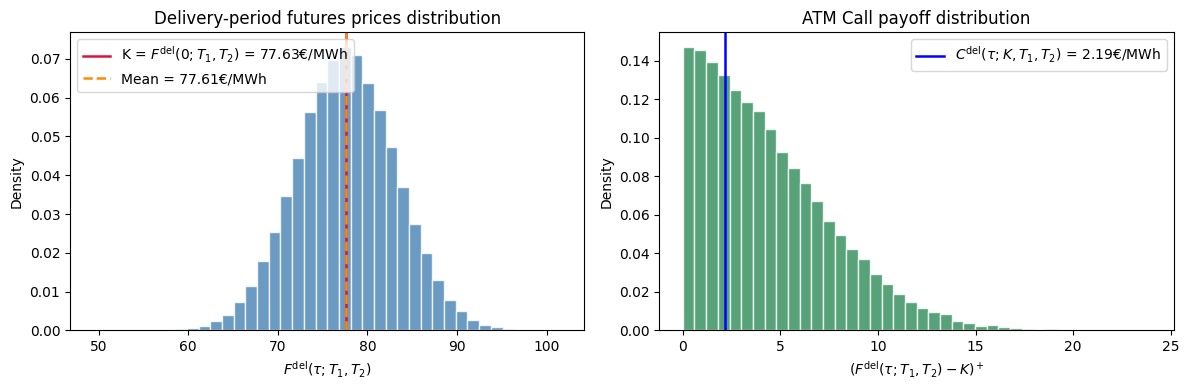

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of Futures prices
axes[0].hist(result['F_del'], bins=40, density=True, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(K, color='crimson', lw=1.8, label=fr'K = $F^{{\rm del}}(0; T_1, T_2)$ = {K:.2f}€/MWh')
axes[0].axvline(result['F_del'].mean(), color='darkorange', lw=1.8, ls='--',
                label=f'Mean = {result["F_del"].mean():.2f}€/MWh')
axes[0].set_xlabel('$F^{\\rm del}(\\tau; T_1, T_2)$')
axes[0].set_ylabel('Density')
axes[0].set_title('Delivery-period futures prices distribution')
axes[0].legend()

# Histogram of payoffs
call_price = result['payoff distribution'].mean()
nonzero = result['payoff distribution'][result['payoff distribution'] > 0]
axes[1].hist(nonzero, bins=40, density=True, color='seagreen', alpha=0.8, edgecolor='white')
axes[1].axvline(call_price,color='blue',lw=1.8,label=fr'$C^{{\rm del}}(\tau; K, T_1, T_2)$ = {call_price:.2f}€/MWh')
axes[1].set_xlabel('$(F^{\\rm del}(\\tau; T_1, T_2) - K)^+$')
axes[1].set_ylabel('Density')
axes[1].set_title('ATM Call payoff distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## ATM Implied Volatility Decreasing with $T_1 - \tau$ 

In [1]:
from scipy.optimize import brentq
from scipy.stats import norm

# -------------------------------------------------------- Black-76 formula

def black76_call(F, K, sigma, tau_years, r):               # tau_years = time_distance(tau, T0)/365*24
    """Call price under Black-76 model"""
    if sigma <= 0 or tau_years <= 0:
        return max(F - K, 0.0)                             # F denotes the current futures price
    d1 = (np.log(F / K) + 0.5 * sigma**2 * tau_years) / (sigma * np.sqrt(tau_years))
    d2 = d1 - sigma * np.sqrt(tau_years)
    return np.exp(-r * tau_years) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def implied_vol_black76(price, F, K, tau_years, r, vol_low=1e-6, vol_high=10.0):
    """Invert Black-76 to find implied volatility"""
    intrinsic = np.exp(-r * tau_years) * max(F - K, 0.0)
    if price <= intrinsic :
        return 0
    try:
        iv = brentq(lambda s: black76_call(F, K, s, tau_years, r) - price, vol_low, vol_high, xtol=1e-4, maxiter=200)
        return iv
    except ValueError:
        return np.nan


# -------------------------------------------------------- Vol smile across maturities
def implied_vol_structure(T0, T1, T2, maturities, N=10_000, r=0, dt=1.0, seed=0):
   
    # Contractual ATM strike 
    n_grid = int(time_distance(T2, T1))
    delivery_grid = list(pd.date_range(start=T1, end=T2, periods=n_grid))

    K = delivery_futures(T1, T2, np.zeros((1, pX)), 0, T0)[0]

    records = []
    for i, tau in enumerate(maturities):
        days_to_delivery = (T1 - tau).total_seconds() / (3600 * 24)
        tau_years        = (tau - T0).total_seconds() / (365.25 * 24 * 3600)
        print(f'[{days_to_delivery:.0f} days before T1]', end=' ')
        
        result    = price_futures_call(T0=T0, tau=tau, T1=T1, T2=T2, K=K, origin_date=origin_date, N=N, r=r, dt=dt, seed=seed)
        price     = result['call price']
        F         = result['F_del'].mean()   # this value becomes the strike in Black's formula

        iv = implied_vol_black76(price=price, F=F, K=K, tau_years=tau_years, r=r)
        print(f'F={F:.2f}  price={price:.4f}  IV={iv*100:.2f}%')
        records.append({
            'tau'              : tau,
            'days_to_delivery' : days_to_delivery,
            'tau_years'        : tau_years,
            'K'                : K,
            'F'                : F,
            'price'            : price,
            'iv'               : iv,
        })

    df = pd.DataFrame(records)
    
    plt.figure(figsize=(8, 4))
    plt.plot(df['days_to_delivery'], df['iv'] * 100,'o-', color='steelblue', lw=2, ms=6)
    plt.xlabel('Time distance $T_1-\\tau$')
    plt.ylabel('ATM implied volatility (%)')
    plt.title(f'ATM implied volatility for the strike \n'f'K={K:.2f} €/MWh  and delivery period [{T1.date()} – {T2.date()}]')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df



In [2]:
#--------------------------------------------------------------- Test

origin_date = pd.Timestamp('2023-01-01 00:00:00')
T0          = pd.Timestamp('2026-06-01 00:00:00')
T1          = pd.Timestamp('2026-07-01 00:00:00')
T2          = pd.Timestamp('2026-07-31 23:00:00')

maturities = [T1 - pd.Timedelta(days=d) for d in [0, 1, 2, 3, 4, 5, 6, 7, 14, 21, 29]]

df_iv = implied_vol_structure(T0=T0, T1=T1, T2=T2, maturities=maturities, N=10_000, r=0)


NameError: name 'pd' is not defined

$$\star \star \star$$